# 02 — Le modèle et la simulation

Résultats du dernier entraînement (`python -m ml.scripts.entrainement`) et exemples de simulation, comme les fera le dashboard.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().resolve().parents[1]))  # racine du projet

import logging

import matplotlib.pyplot as plt
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s", force=True)

In [2]:
import json

from ml.scripts.config import FICHIER_METRIQUES

m = json.loads(FICHIER_METRIQUES.read_text())
print("Version :", m["version"], "| modèle :", m["modele"])
print(pd.Series(m["validation"], name="MAE validation 2006-2010").round(3))
pd.DataFrame({"modèle": m["test"]["modele"], "baseline région × produit": m["test"]["baseline_region_produit"]}).T.round(3)

Version : 20261008_004640 | modèle : {'type': 'lasso', 'alpha': 0.001}
lineaire                0.750
ridge (alpha=0.1)       0.669
ridge (alpha=1)         0.614
ridge (alpha=10)        0.650
ridge (alpha=100)       0.683
lasso (alpha=0.0003)    0.584
lasso (alpha=0.001)     0.578
lasso (alpha=0.003)     0.628
lasso (alpha=0.01)      0.709
Name: MAE validation 2006-2010, dtype: float64


,n,mae,rmse,r2
modèle,1241.0,0.608,1.387,0.655
baseline région × produit,1241.0,0.634,1.477,0.609


## Erreur par culture (sur test, 2011-2015)

In [3]:
pd.DataFrame(m["test"]["par_produit"]).T.round(3)

,n,mae_modele,mae_baseline
Arachide (en coque),189.0,0.219,0.215
Fonio,28.0,0.137,0.141
Manioc,122.0,2.592,2.980
Maïs,178.0,0.517,0.413
Mil,173.0,0.159,0.157
Niébé,176.0,0.133,0.142
Patate douce,5.0,8.686,8.608
Riz,136.0,1.067,1.142
Sorgho,180.0,0.245,0.249
Sésame,54.0,0.316,0.176


## Simuler une campagne

Sans pluie saisie et sans climat observé, le modèle utilise la normale de la région.

In [4]:
from ml.scripts.simulation import simuler

simuler(produit="Mil", region="Kaolack", superficie_ha=1000, annee=2027)

{'rendement_t_ha': 0.74,
 'production_t': 740.3,
 'climat': {'source': 'normale_region',
  'pluie_cumul_mm': 498.1,
  'tavg_moyenne': 29.03,
  'pluie_normale_mm': 498.1,
  'station_utilisee': 'Kaolack'},
 'reperes': {'rendement_moyen_historique_t_ha': 0.737,
  'erreur_moyenne_test_t_ha': 0.159},
 'modele_version': '20261008_004640'}

## Scénarios : et si la pluie était de… ?

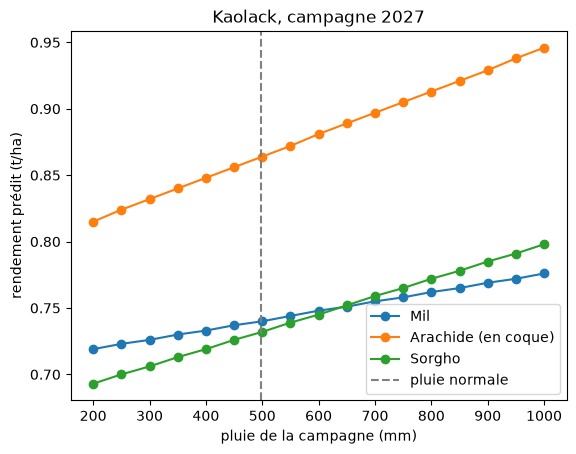

In [5]:
pluies = range(200, 1001, 50)
for produit in ["Mil", "Arachide (en coque)", "Sorgho"]:
    rendements = [simuler(produit, "Kaolack", 1000, 2027, pluie_cumul_mm=p)["rendement_t_ha"] for p in pluies]
    plt.plot(list(pluies), rendements, marker="o", label=produit)
plt.axvline(simuler("Mil", "Kaolack", 1000, 2027)["climat"]["pluie_normale_mm"], color="grey", ls="--", label="pluie normale")
plt.xlabel("pluie de la campagne (mm)"); plt.ylabel("rendement prédit (t/ha)"); plt.title("Kaolack, campagne 2027")
plt.legend(); plt.show()